# Spotify Dataset Cleaning and EDA



## 1. Import libraries

We start by importing the libraries needed for data handling and visualization.

In [9]:
import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load all datasets

There are five CSV files in this project. We will load all of them first.

In [10]:
songs_df = pd.read_csv('data.csv')
artist_df = pd.read_csv('data_by_artist.csv')
genre_df = pd.read_csv('data_by_genres.csv')
year_df = pd.read_csv('data_by_year.csv')
artist_genre_df = pd.read_csv('data_w_genres.csv')

print('songs_df shape        :', songs_df.shape)
print('artist_df shape       :', artist_df.shape)
print('genre_df shape        :', genre_df.shape)
print('year_df shape         :', year_df.shape)
print('artist_genre_df shape :', artist_genre_df.shape)

songs_df shape        : (170653, 19)
artist_df shape       : (28680, 15)
genre_df shape        : (2973, 14)
year_df shape         : (100, 14)
artist_genre_df shape : (28680, 16)


## 3. Preview the data

Looking at the first few rows helps us understand what each dataset contains.

In [11]:
songs_df.head(3)

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339


In [12]:
artist_df.head(3)

,mode,count,acousticness,artists,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,9,0.590111,"""Cats"" 1981 Original London Cast",0.467222,250318.555556,0.394003,0.011400,0.290833,-14.448000,0.210389,117.518111,0.389500,38.333333,5
1,1,26,0.862538,"""Cats"" 1983 Broadway Cast",0.441731,287280.000000,0.406808,0.081158,0.315215,-10.690000,0.176212,103.044154,0.268865,30.576923,5
2,1,7,0.856571,"""Fiddler On The Roof” Motion Picture Chorus",0.348286,328920.000000,0.286571,0.024593,0.325786,-15.230714,0.118514,77.375857,0.354857,34.857143,0


In [13]:
genre_df.head(3)

,mode,genres,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,21st century classical,0.979333,0.162883,1.602977e+05,0.071317,0.606834,0.3616,-31.514333,0.040567,75.336500,0.103783,27.833333,6
1,1,432hz,0.494780,0.299333,1.048887e+06,0.450678,0.477762,0.1310,-16.854000,0.076817,120.285667,0.221750,52.500000,5
2,1,8-bit,0.762000,0.712000,1.151770e+05,0.818000,0.876000,0.1260,-9.180000,0.047000,133.444000,0.975000,48.000000,7


## 4. Basic information about each dataset



In [14]:
datasets = {
    'songs_df': songs_df,
    'artist_df': artist_df,
    'genre_df': genre_df,
    'year_df': year_df,
    'artist_genre_df': artist_genre_df
}

for name, df in datasets.items():
    print(f'\n{name}')
    print('-' * 60)
    print('Rows, Columns :', df.shape)
    print('\nMissing values:')
    print(df.isnull().sum())
    print('\nDuplicate rows :', df.duplicated().sum())


songs_df
------------------------------------------------------------
Rows, Columns : (170653, 19)

Missing values:
valence             0
year                0
acousticness        0
artists             0
danceability        0
duration_ms         0
energy              0
explicit            0
id                  0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
name                0
popularity          0
release_date        0
speechiness         0
tempo               0
dtype: int64

Duplicate rows : 0

artist_df
------------------------------------------------------------
Rows, Columns : (28680, 15)

Missing values:
mode                0
count               0
acousticness        0
artists             0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
key    

### Observation

The good part is that these datasets do not have missing values or duplicate rows.

So our cleaning work will focus on:
- fixing data formats
- converting date columns
- parsing list-like text columns
- creating useful new columns for analysis

## 5. Clean the main songs dataset

The main dataset `data.csv` contains song-level information. We will make it easier to analyze by converting dates and extracting useful features.

In [15]:
songs_clean = songs_df.copy()

# Convert release_date into datetime format
songs_clean['release_date'] = pd.to_datetime(songs_clean['release_date'], errors='coerce')

# Create useful columns for analysis
songs_clean['release_year'] = songs_clean['release_date'].dt.year
songs_clean['release_month'] = songs_clean['release_date'].dt.month
songs_clean['duration_min'] = songs_clean['duration_ms'] / 60000

# Convert explicit column from 0/1 into readable labels
songs_clean['explicit_label'] = songs_clean['explicit'].map({0: 'No', 1: 'Yes'})

# Convert artists from string format into a proper Python list
songs_clean['artist_list'] = songs_clean['artists'].apply(ast.literal_eval)
songs_clean['artist_count'] = songs_clean['artist_list'].apply(len)
songs_clean['primary_artist'] = songs_clean['artist_list'].apply(lambda x: x[0] if len(x) > 0 else np.nan)

songs_clean[['name', 'artists', 'primary_artist', 'artist_count', 'release_date', 'duration_min']].head()

,name,artists,primary_artist,artist_count,release_date,duration_min
0,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...","['Sergei Rachmaninoff', 'James Levine', 'Berli...",Sergei Rachmaninoff,3,1921-01-01,13.861117
1,Clancy Lowered the Boom,['Dennis Day'],Dennis Day,1,1921-01-01,3.008883
2,Gati Bali,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,KHP Kridhamardawa Karaton Ngayogyakarta Hadini...,1,1921-01-01,8.334367
3,Danny Boy,['Frank Parker'],Frank Parker,1,1921-01-01,3.500000
4,When Irish Eyes Are Smiling,['Phil Regan'],Phil Regan,1,1921-01-01,2.778217


## 6. Clean the artist, genre, and year datasets



In [16]:
artist_clean = artist_df.copy()
genre_clean = genre_df.copy()
year_clean = year_df.copy()
artist_genre_clean = artist_genre_df.copy()

# Create duration in minutes for readability
artist_clean['duration_min'] = artist_clean['duration_ms'] / 60000
genre_clean['duration_min'] = genre_clean['duration_ms'] / 60000
year_clean['duration_min'] = year_clean['duration_ms'] / 60000
artist_genre_clean['duration_min'] = artist_genre_clean['duration_ms'] / 60000

# Clean text columns
artist_clean['artists'] = artist_clean['artists'].str.strip()
genre_clean['genres'] = genre_clean['genres'].str.strip()
artist_genre_clean['artists'] = artist_genre_clean['artists'].str.strip()

# Parse genre list in data_w_genres.csv
artist_genre_clean['genre_list'] = artist_genre_clean['genres'].apply(ast.literal_eval)
artist_genre_clean['genre_count'] = artist_genre_clean['genre_list'].apply(len)
artist_genre_clean['primary_genre'] = artist_genre_clean['genre_list'].apply(
    lambda x: x[0] if len(x) > 0 else 'Unknown'
)

artist_genre_clean[['artists', 'genres', 'primary_genre', 'genre_count']].head()

,artists,genres,primary_genre,genre_count
0,"""Cats"" 1981 Original London Cast",['show tunes'],show tunes,1
1,"""Cats"" 1983 Broadway Cast",[],Unknown,0
2,"""Fiddler On The Roof” Motion Picture Chorus",[],Unknown,0
3,"""Fiddler On The Roof” Motion Picture Orchestra",[],Unknown,0
4,"""Joseph And The Amazing Technicolor Dreamcoat""...",[],Unknown,0


## 7. Save cleaned datasets

This is a good practice because after cleaning, we can reuse the cleaned files without doing the same work again.

In [17]:
songs_clean.to_csv('cleaned_data.csv', index=False)
artist_clean.to_csv('cleaned_data_by_artist.csv', index=False)
genre_clean.to_csv('cleaned_data_by_genres.csv', index=False)
year_clean.to_csv('cleaned_data_by_year.csv', index=False)
artist_genre_clean.to_csv('cleaned_data_w_genres.csv', index=False)

print('Cleaned files saved successfully.')

Cleaned files saved successfully.


## 8. Descriptive statistics



In [18]:
songs_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
valence,170653.0,0.528587,0.0,0.317,0.54,0.747,1.0,0.263171
year,170653.0,1976.787241,1921.0,1956.0,1977.0,1999.0,2020.0,25.917853
acousticness,170653.0,0.502115,0.0,0.102,0.516,0.893,0.996,0.376032
danceability,170653.0,0.537396,0.0,0.415,0.548,0.668,0.988,0.176138
duration_ms,170653.0,230948.310666,5108.0,169827.0,207467.0,262400.0,5403500.0,126118.414668
energy,170653.0,0.482389,0.0,0.255,0.471,0.703,1.0,0.267646
explicit,170653.0,0.084575,0.0,0.0,0.0,0.0,1.0,0.278249
instrumentalness,170653.0,0.16701,0.0,0.0,0.000216,0.102,1.0,0.313475
key,170653.0,5.199844,0.0,2.0,5.0,8.0,11.0,3.515094
liveness,170653.0,0.205839,0.0,0.0988,0.136,0.261,1.0,0.174805


## 9. Distribution of popularity

This histogram shows how song popularity is distributed.

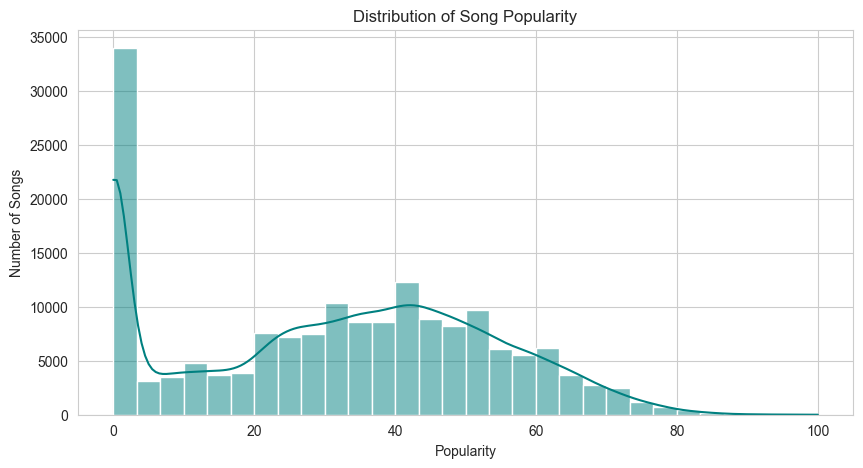

In [19]:
plt.figure(figsize=(10, 5))
sns.histplot(songs_clean['popularity'], bins=30, kde=True, color='teal')
plt.title('Distribution of Song Popularity')
plt.xlabel('Popularity')
plt.ylabel('Number of Songs')
plt.show()

### Observation

Most songs have low to medium popularity, and only a small number of songs have very high popularity.

## 10. Top 10 most popular songs

This helps us identify the songs with the highest popularity score.

In [20]:
top_songs = songs_clean[['name', 'primary_artist', 'popularity', 'year']].sort_values(
    by='popularity', ascending=False
).head(10)

top_songs

,name,primary_artist,popularity,year
19611,Dakiti,Bad Bunny,100,2020
19606,Mood (feat. iann dior),24kGoldn,99,2020
19618,Dynamite,BTS,97,2020
19616,Blinding Lights,The Weeknd,96,2020
19608,WAP (feat. Megan Thee Stallion),Cardi B,96,2020
19610,positions,Ariana Grande,96,2020
19612,What You Know Bout Love,Pop Smoke,96,2020
19615,Holy (feat. Chance The Rapper),Justin Bieber,95,2020
19607,For The Night (feat. Lil Baby & DaBaby),Pop Smoke,95,2020
19623,you broke me first,Tate McRae,95,2020


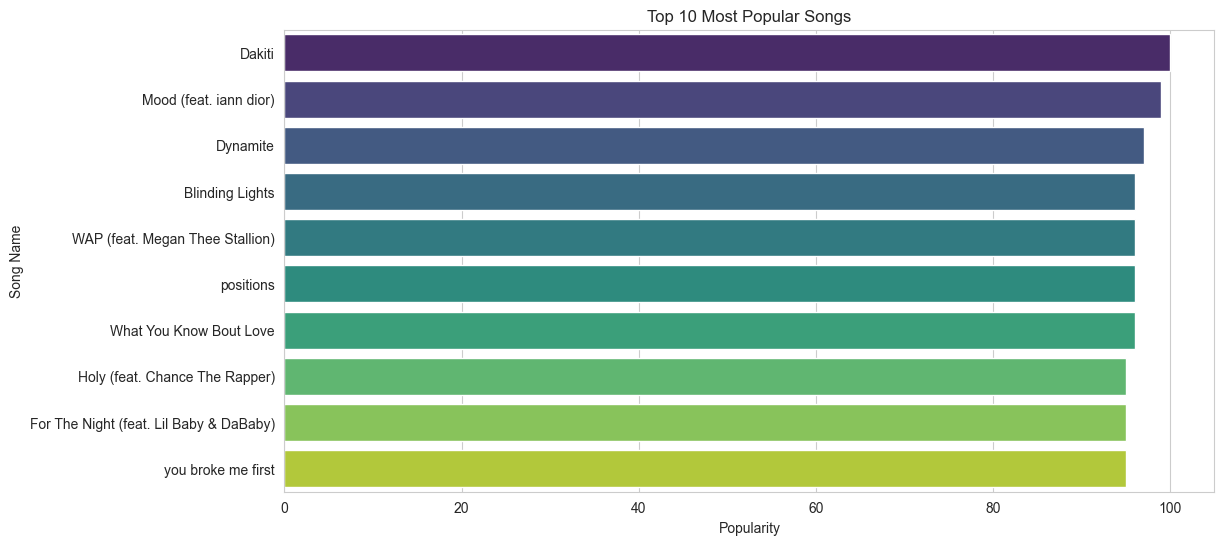

In [21]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_songs, x='popularity', y='name', palette='viridis')
plt.title('Top 10 Most Popular Songs')
plt.xlabel('Popularity')
plt.ylabel('Song Name')
plt.show()

## 11. Correlation between numerical features

A heatmap helps us understand how different audio features are related.

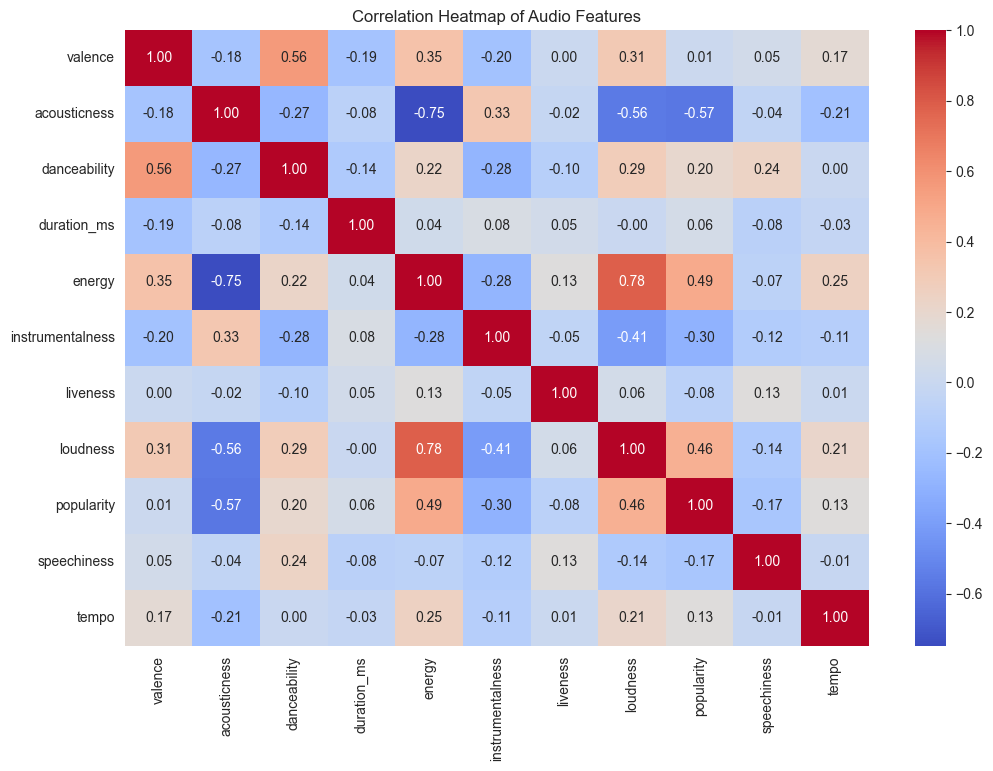

In [22]:
num_cols = [
    'valence', 'acousticness', 'danceability', 'duration_ms', 'energy',
    'instrumentalness', 'liveness', 'loudness', 'popularity',
    'speechiness', 'tempo'
]

corr_matrix = songs_clean[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Correlation Heatmap of Audio Features')
plt.show()

### Observation

The heatmap shows both positive and negative relationships. For example, energy and loudness usually move together, while acousticness often has a negative relationship with energy.

## 12. Popularity over the years

This graph shows how average popularity changes from year to year.

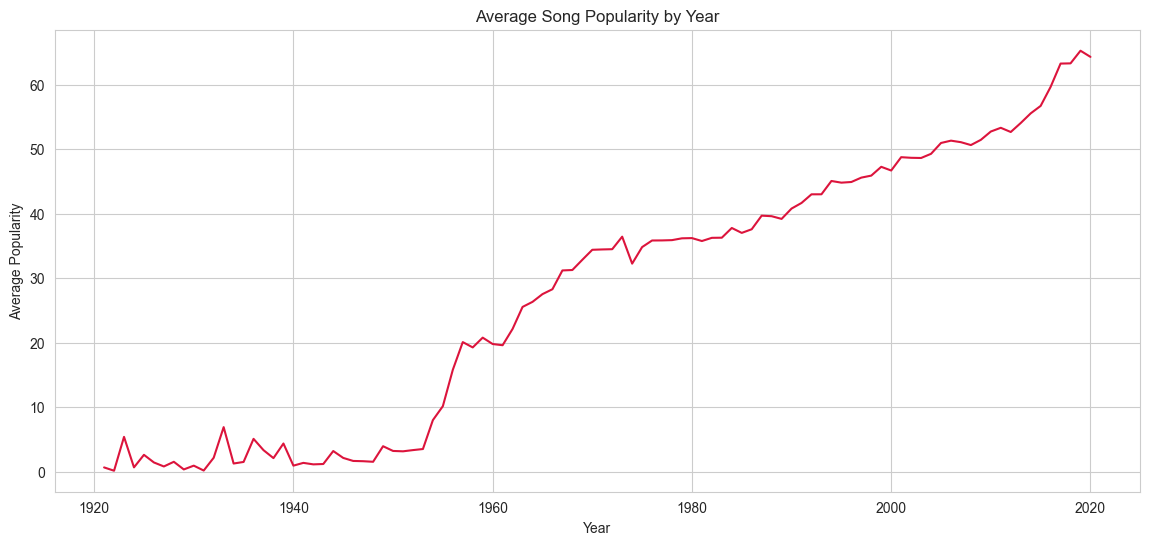

In [23]:
popularity_by_year = songs_clean.groupby('year')['popularity'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=popularity_by_year, x='year', y='popularity', color='crimson')
plt.title('Average Song Popularity by Year')
plt.xlabel('Year')
plt.ylabel('Average Popularity')
plt.show()

## 13. Danceability vs Energy

This scatter plot helps us see whether highly energetic songs are also more danceable.

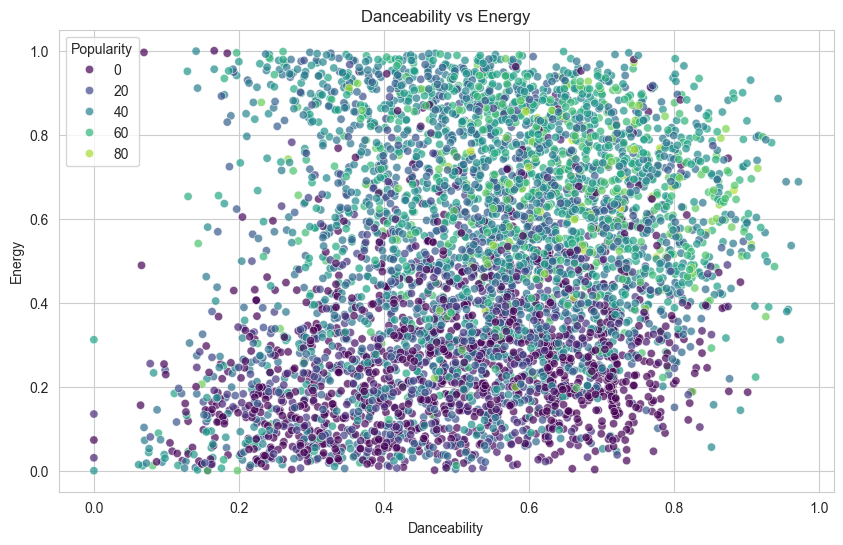

In [24]:
sample_df = songs_clean.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_df,
    x='danceability',
    y='energy',
    hue='popularity',
    palette='viridis',
    alpha=0.7
)
plt.title('Danceability vs Energy')
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.legend(title='Popularity')
plt.show()

## 14. Explicit songs vs non-explicit songs

Here we compare whether explicit songs have different popularity levels.

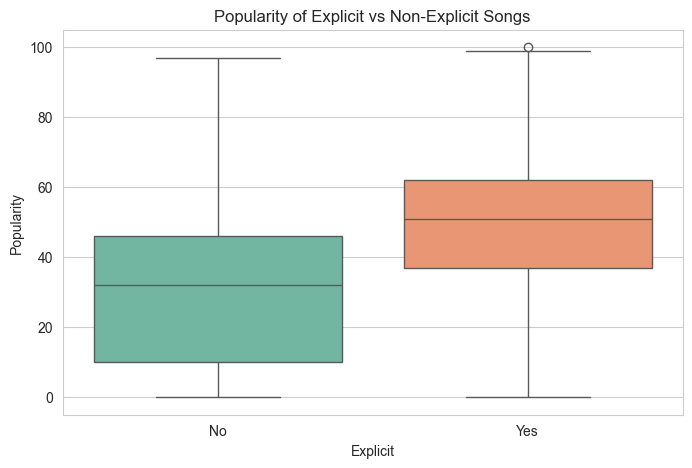

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=songs_clean, x='explicit_label', y='popularity', palette='Set2')
plt.title('Popularity of Explicit vs Non-Explicit Songs')
plt.xlabel('Explicit')
plt.ylabel('Popularity')
plt.show()

## 15. Top 10 genres by popularity

Now we move to the genre dataset to see which genres have the highest average popularity.

In [26]:
top_genres = genre_clean[['genres', 'popularity']].sort_values(
    by='popularity', ascending=False
).head(10)

top_genres

,genres,popularity
237,basshall,80.666667
2755,trap venezolano,80.000000
2533,south african house,80.000000
2778,turkish edm,80.000000
46,alberta hip hop,78.500000
536,chinese electropop,78.500000
37,afroswing,77.312500
1381,indie triste,77.000000
1239,guaracha,77.000000
2383,russian dance,77.000000


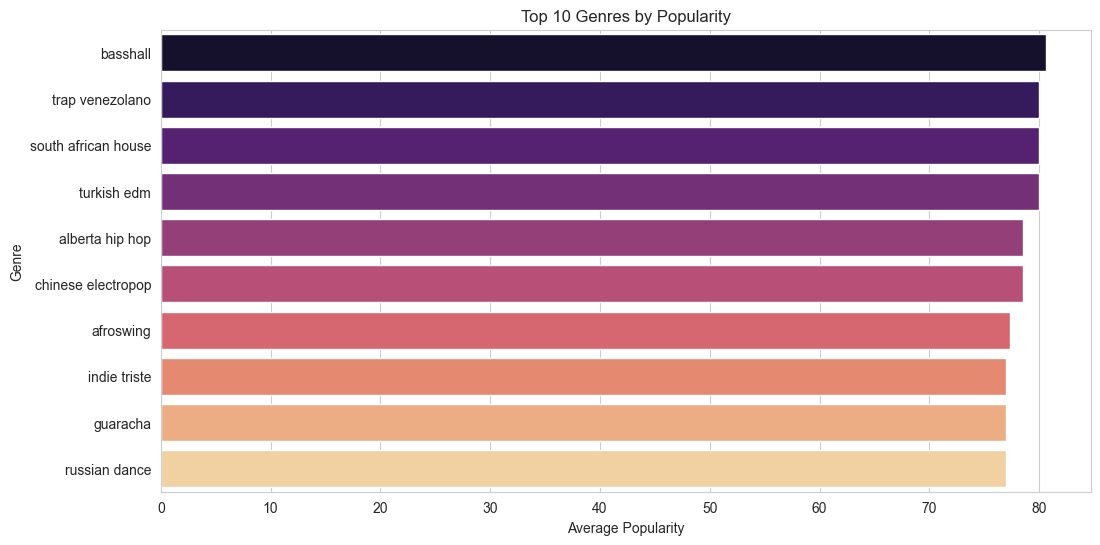

In [27]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_genres, x='popularity', y='genres', palette='magma')
plt.title('Top 10 Genres by Popularity')
plt.xlabel('Average Popularity')
plt.ylabel('Genre')
plt.show()

## 16. Top 10 artists by popularity

This shows the artists with the highest average popularity score.

In [28]:
top_artists = artist_clean[['artists', 'popularity', 'count']].sort_values(
    by='popularity', ascending=False
).head(10)

top_artists

,artists,popularity,count
20966,Ritt Momney,93.0,2
14354,Lele Pons,92.0,1
15070,Los Legendarios,90.0,2
11764,Jerry Di,89.0,2
7463,Emilee,88.0,2
28263,salem ilese,88.0,2
23687,Surf Mesa,88.0,1
213,A7S,87.0,3
14378,Lenny Santos,86.0,2
16453,Master KG,86.0,1


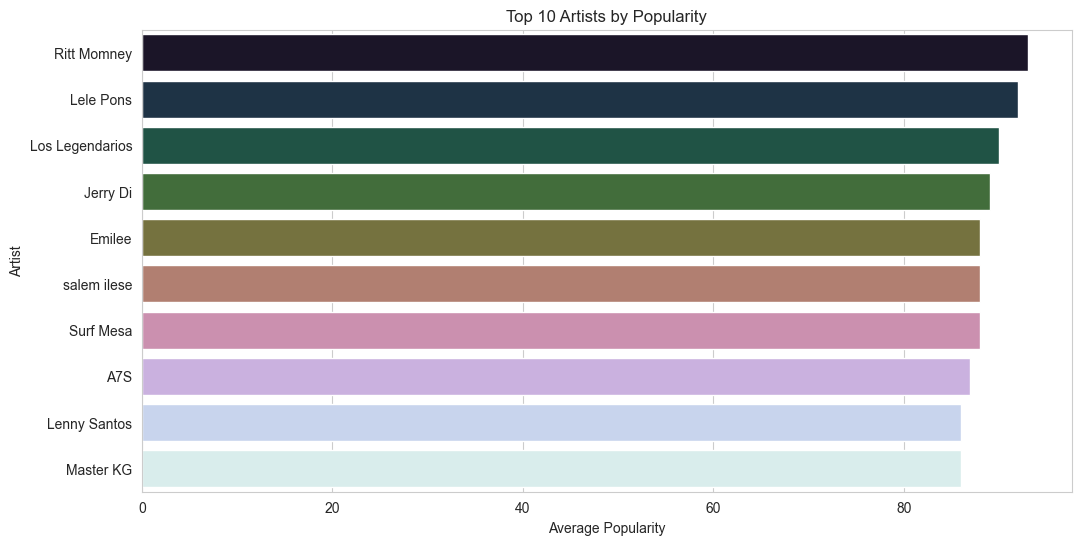

In [29]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_artists, x='popularity', y='artists', palette='cubehelix')
plt.title('Top 10 Artists by Popularity')
plt.xlabel('Average Popularity')
plt.ylabel('Artist')
plt.show()

## 17. Trends in audio features by year

This section helps us understand how music characteristics changed over time.

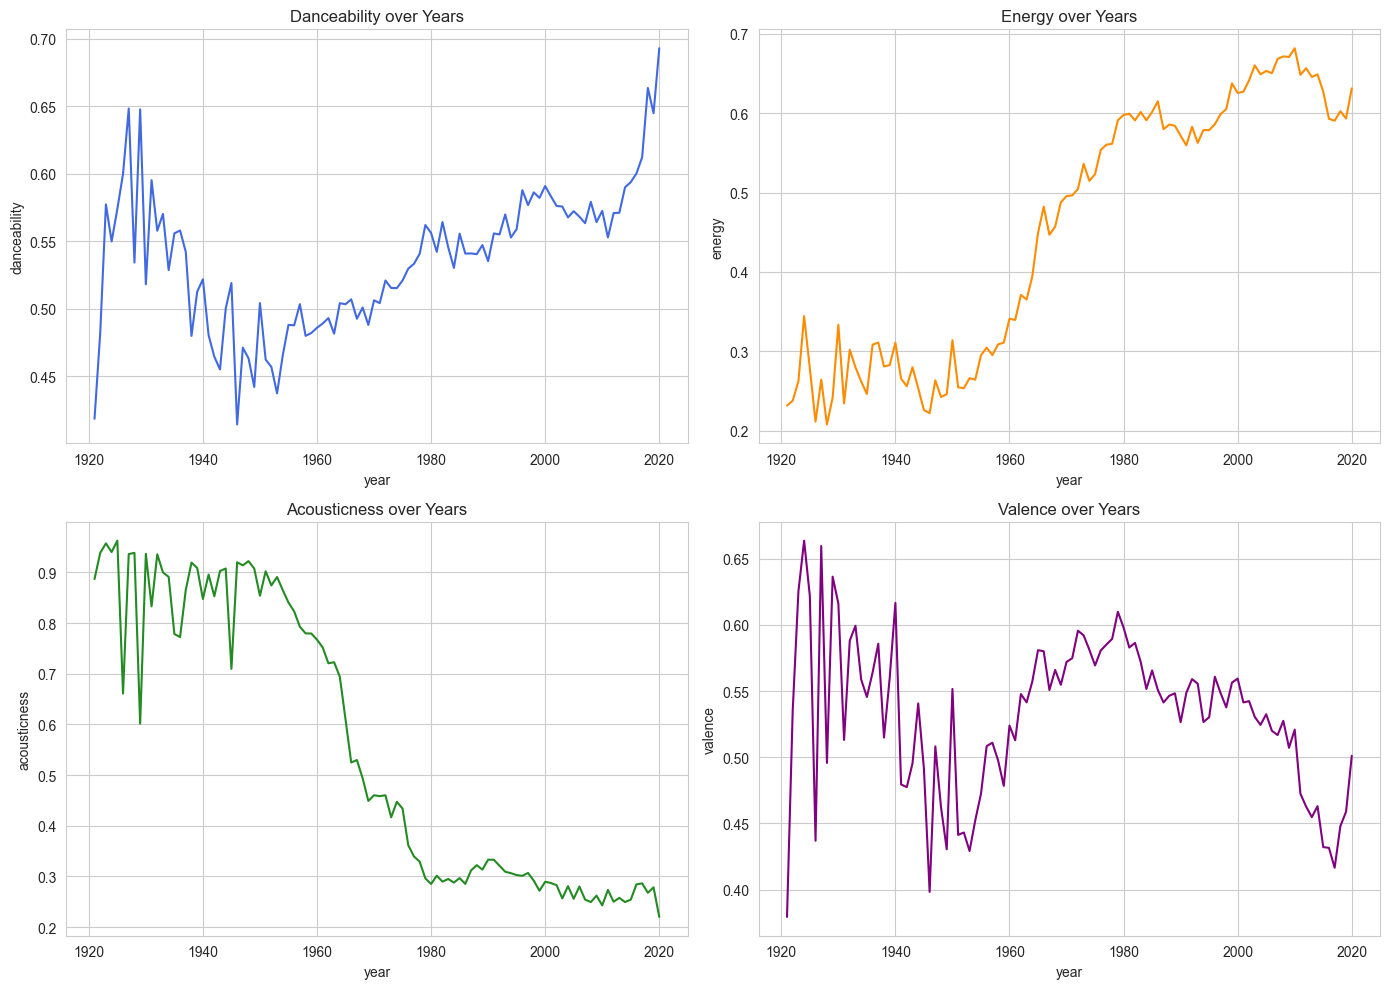

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.lineplot(data=year_clean, x='year', y='danceability', ax=axes[0, 0], color='royalblue')
axes[0, 0].set_title('Danceability over Years')

sns.lineplot(data=year_clean, x='year', y='energy', ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Energy over Years')

sns.lineplot(data=year_clean, x='year', y='acousticness', ax=axes[1, 0], color='forestgreen')
axes[1, 0].set_title('Acousticness over Years')

sns.lineplot(data=year_clean, x='year', y='valence', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Valence over Years')

plt.tight_layout()
plt.show()

## 18. Final conclusion

Main points from this project:

- The datasets were already clean in terms of missing values and duplicates.
- The main cleaning work was standardization, date conversion, and feature engineering.
- Most songs in the dataset have low to medium popularity.
- Energy and loudness are positively related.
- Acousticness often shows an opposite trend compared to energy.
- Popularity, genre, and audio features change over time.

